In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to Rent database & load data

Loading Rent_Stage_1 dataset to dataframe and create a copy.

In [2]:
conn = sqlite3.connect('Rent.db')

In [3]:
query = "SELECT * FROM Rent_Stage_1"
df_raw = pd.read_sql(query,conn)

In [4]:
df = df_raw.copy()

# 2. Dataset overview & Summary Statistics

Perform an initial inspection of the dataset's structure, data types, and generate descriptive statiscs for both numeric and categorical

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70847 entries, 0 to 70846
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    70847 non-null  object 
 1   date                  70847 non-null  object 
 2   city                  70847 non-null  object 
 3   type                  54085 non-null  object 
 4   squareMeters          70847 non-null  float64
 5   rooms                 70847 non-null  float64
 6   floor                 62234 non-null  float64
 7   floorCount            69468 non-null  float64
 8   buildYear             51165 non-null  float64
 9   latitude              70847 non-null  float64
 10  longitude             70847 non-null  float64
 11  centreDistance        70847 non-null  float64
 12  poiCount              70847 non-null  float64
 13  schoolDistance        70832 non-null  float64
 14  clinicDistance        70797 non-null  float64
 15  postOfficeDistance 

**Insight:** column date has wrong type I must change to datatime.

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.shape

(70847, 28)

In [8]:
df.describe()

,date,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price,price_per_m2
count,70847,70847.000000,70847.000000,62234.000000,69468.000000,51165.000000,70847.000000,70847.000000,70847.000000,70847.000000,70832.000000,70797.000000,70821.000000,70804.000000,70693.000000,69973.000000,70767.000000,70847.000000,70847.000000
mean,2024-02-17 01:21:24.215280640,55.252692,2.384942,3.419787,5.686906,1998.109293,51.785566,19.691005,3.856228,25.207983,0.368818,0.776294,0.470210,0.327194,0.260977,1.286804,0.308887,3852.796886,69.203438
min,2023-11-01 00:00:00,25.000000,1.000000,1.000000,1.000000,1850.000000,49.982150,14.447100,0.020000,0.000000,0.002000,0.001000,0.001000,0.001000,0.001000,0.004000,0.001000,346.000000,11.300000
25%,2024-01-01 00:00:00,40.000000,2.000000,2.000000,4.000000,1984.000000,51.078600,18.651526,1.770000,9.000000,0.174000,0.302000,0.235000,0.153000,0.087000,0.520000,0.136000,2500.000000,53.000000
50%,2024-03-01 00:00:00,50.000000,2.000000,3.000000,5.000000,2010.000000,52.185642,19.958724,3.380000,17.000000,0.285000,0.550000,0.388000,0.259000,0.180000,0.971000,0.231000,3100.000000,65.960000
75%,2024-05-01 00:00:00,64.000000,3.000000,4.000000,7.000000,2020.000000,52.250101,21.005240,5.420000,30.000000,0.449000,0.970000,0.585000,0.401000,0.329000,1.809000,0.382000,4490.000000,81.580000
max,2024-06-01 00:00:00,150.000000,6.000000,30.000000,30.000000,2024.000000,54.581756,23.199087,16.620000,210.000000,4.856000,4.990000,4.939000,4.751000,4.961000,5.000000,4.986000,23000.000000,189.470000
std,NaN,22.688973,0.872078,2.647224,3.461192,30.292490,1.183777,1.675260,2.609485,27.050432,0.341474,0.724202,0.389788,0.321697,0.318860,1.016936,0.327246,2381.540981,23.349050


**Insights:** Analyzing the table, we can notice potential outliers in the **price** column, where the minimum value is 346 PLN, and in the **price_per_m2 column**, where the minimum value is 11.3 PLN. We will address these values during the EDA stage. The remaining values appear to be realistic.

In [9]:
df.describe(include='object')

,id,city,type,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom
count,70847,70847,54085,70847,70847,70847,66923,70847,70847
unique,37941,15,3,1,2,2,2,2,2
top,f669872f67ece87f8e8fce68ac27f31a,warszawa,apartmentBuilding,condominium,no,yes,yes,no,no
freq,8,28414,23910,70847,43075,43506,44063,60614,59833


# 3. Automated Data Quality Audit

Design a custom, resuable Python class 'DataQualityChecker' to systematically identify missing values and track duplicate records across the dataset.

In [10]:
class DataQualityChecker:
    def __init__(self,dataframe):
        self.df = dataframe
    def check_missing(self):
        missing_value_pct = ((self.df.isnull().sum()) / len(self.df)) * 100
        return missing_value_pct[missing_value_pct > 0].sort_values(ascending=False).round(5)
    def check_duplicates(self):
        duplicated = self.df.duplicated().sum()
        print(f"Total duplicate rows in dataset: {duplicated}")

In [11]:
check = DataQualityChecker(df)

In [12]:
check.check_missing()

buildYear               27.78099
type                    23.65944
floor                   12.15718
hasElevator              5.53870
floorCount               1.94645
collegeDistance          1.23364
restaurantDistance       0.21737
pharmacyDistance         0.11292
clinicDistance           0.07057
kindergartenDistance     0.06069
postOfficeDistance       0.03670
schoolDistance           0.02117
dtype: float64

**Insights:** In this dataset, we have 12 columns with missing values. In the next step, we will impute these values or drop the affected records.

In [13]:
check.check_duplicates()

Total duplicate rows in dataset: 0


**Insights:** We found no duplicated records in this dataset.

# 4. Advanced Data Imputation & Cleaning

Design a custom, resuable Python class 'DataInputer' which contains custom methods for missing data imputation.

In [14]:
((df['type'].isna()) & (df['buildYear'].isna())).sum()

np.int64(7736)

**Insight:** I got 7736 records with missing value in two both columns.

 Below is a breakdown of these methods and their underlying logic:
* **distance_values** - This method handles missing values in distance-related columns by applying city-level median.
*  **floorCount** - Fills missing values with the city-level-median, followed by the global median to ensure no nulls are left behind.
*  **elevator** - Uses domain knowledge (Polish building law) to fill values: assign 'no' to buildings with <=4 florrs and 'yes' to those with > 4 floors. Any leftover nulls are defaulted to 'no'
*  **type** - This method applies a robust 3-stage imputation strategy. **Stage 1** uses domain knowledge regarding historical architectural periods in Poland to infer the building type based on the construction year. **Stage 2** targests 7736 records missing both **type** and **buildYear** by applying the group-level-mode based on **city** and **floorCount**. **Stage 3** acts as a final fallback, filling any remaining nulls with global mode.
*  **year** - This method imputes missing construction years by calculating the group-level-median based on the **city** and **type** columns , ensuring architectural and regional consistency.
*  **floor** - Applies a two-step grouped imputation strategy. It first calculates the median floor based on **city**, **type**, and **floorCount**. Any residual missing values are filled using the overall **floorCount** median. Finally, all values are rounded to preserve discrete integer types.

In [15]:
class DataImputer:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
    def distance_values(self,column):
        median_city = self.df.groupby('city')[column].transform('median')
        self.df[column] = self.df[column].fillna(median_city)
    def floorCount(self,column):
        median_floorCount = self.df.groupby('city')[column].transform('median')
        self.df[column] = self.df[column].fillna(median_floorCount)
        if self.df[column].isna().any():
            self.df[column] = self.df[column].fillna(self.df[column].median())
    def elevator(self,column):
        self.df.loc[(self.df['floorCount'] <= 4) & (self.df[column].isna()), column] = 'no'
        self.df.loc[(self.df['floorCount'] > 4) & (self.df[column].isna()), column] = 'yes'
        if self.df[column].isna().any():
            self.df[column] = self.df[column].fillna('no')
    def type(self,column):
        def _impute_row(row):
            if pd.notna(row[column]):
                return row[column]
            if pd.notna(row['buildYear']):
                year = row['buildYear']
                if year < 1950:
                    return 'tenement'
                elif 1950 <= year <=2010 :
                    return 'blockOfFlats'
                elif year > 2010:
                    return 'apartmentBuilding'
            return row[column]
        self.df[column] = self.df.apply(_impute_row, axis=1)
        self.df[column] = self.df[column].fillna(self.df.groupby(['city', 'floorCount'])[column].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))
        self.df[column] = self.df[column].fillna(self.df[column].mode()[0])
    def year(self,column):
        self.df[column] = self.df[column].fillna(self.df.groupby(['city','type'])[column].transform('median'))
    def floor(self,column):
        self.df[column] = self.df[column].fillna(self.df.groupby(['city','type','floorCount'])[column].transform('median'))
        self.df[column] = self.df[column].fillna(self.df.groupby('floorCount')[column].transform('median'))
        self.df[column] = self.df[column].round()
        

In [16]:
columns = ['kindergartenDistance','clinicDistance','pharmacyDistance','collegeDistance','restaurantDistance','postOfficeDistance','schoolDistance']
imputer = DataImputer(df)
for c in columns:
    imputer.distance_values(c)
imputer.floorCount('floorCount')
imputer.elevator('hasElevator')
imputer.type('type')
imputer.year('buildYear')
imputer.floor('floor')
df = imputer.df
check_final = DataQualityChecker(df)

In [17]:
check_final.check_missing()

Series([], dtype: float64)

**Insights:** All data imputed.

In [18]:
df['floor'] = df['floor'].astype(int)
df['floorCount'] = df['floorCount'].astype(int)

# 4. Exploratory Data Analysis

## 4.1 Data Preprocessing

Design a custom function to mapping binary variables from  'yes/no' to 1/0.

In [19]:
columns_to_mapping = ['hasParkingSpace','hasBalcony','hasElevator','hasSecurity','hasStorageRoom']
mapping_dict = {'yes':1,
                 'no':0}
for col in columns_to_mapping:
    df[col] = df[col].map(mapping_dict)
    
    

**Insight** All data mapped corectly.

In [20]:
df.head()

,id,date,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,...,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,price_per_m2
0,2a1a6db97ff122d6bc148abb6f0e498a,2023-11-01,szczecin,blockOfFlats,52.0,2.0,3,3,2008.0,53.460535,...,2.200,0.307,condominium,1,1,0,0,0,3500,67.31
1,5a0cb42c088eadf75aa98a4118640048,2023-11-01,szczecin,blockOfFlats,57.0,3.0,5,10,1976.0,53.440955,...,1.323,0.189,condominium,0,1,1,0,0,3000,52.63
2,996722490efcb4b34d48bb84a9a72838,2023-11-01,szczecin,blockOfFlats,43.4,2.0,3,4,1995.0,53.435746,...,0.714,0.211,condominium,0,1,0,0,0,1900,43.78
3,50d75c688530b9a61ba505301e0b94a9,2023-11-01,szczecin,apartmentBuilding,32.6,2.0,5,6,2021.0,53.421582,...,0.689,0.192,condominium,0,1,1,0,0,2500,76.69
4,9b187f4203adabf466fd08610d8f4e5e,2023-11-01,szczecin,apartmentBuilding,72.0,3.0,6,6,2014.0,53.450010,...,1.387,0.315,condominium,0,1,1,0,1,2999,41.65


## 4.2 Visualization Helper Class

Design a custom python class 'DataVisualizer' which contains custom methods to create a standardized and aesthethic graphs for EDA.

In [21]:
class DataVisualizer:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
    def histplots(self,columns,titles, axis_x,n,m):
        sns.set_style('whitegrid')
        fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(15,10))
        fig.suptitle('Distribution of Continuous Variables', fontsize=12)
        axes = axes.flatten()
        for i,(col, title,x) in enumerate(zip(columns, titles, axis_x)):
            sns.histplot(self.df[col], kde=True, bins=30, ax = axes[i])
            axes[i].set_title(title)
            axes[i].set_xlabel(x)
            axes[i].set_ylabel('Number of Apartments')
        for j in range(len(columns), n*m):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
    def boxplots(self,columns,titles, axis_x):
        sns.set_style('whitegrid')
        for i,(col, title, x) in enumerate(zip(columns, titles, axis_x)):
            plt.figure(figsize=(14,3))
            sns.boxplot(x = self.df[col])
            plt.title(f"Boxplot for {title}")
            plt.xlabel(x)
            plt.show()
    def countplots(self,columns,titles,y_label):
        for i, (col, title) in enumerate(zip(columns, titles)):
            plt.figure(figsize=(8,10))
            sns.countplot(data = self.df, x = col, order=self.df[col].value_counts().index,hue=col, palette='viridis',legend=False)
            plt.title(title)
            plt.ylabel(y_label)
            plt.xticks(rotation=45)
            plt.show()
    def barplots(self, col1,col2,title):
        plt.figure(figsize=(10,8))
        sns.barplot(data=self.df, x=col1, y=col2, palette='mako',hue=col1,legend=False)
        plt.title(title)
        plt.show()
    def heatmap(self):
        df_numeric = self.df.select_dtypes(include='number')
        correlations = df_numeric.corr()
        plt.figure(figsize=(12,10))
        sns.heatmap(correlations, cmap='inferno',annot=True, fmt='.2f',square=True)
        plt.show()
    def scatterplots(self, col1, col2,title):
        plt.figure(figsize=(15,10))
        sns.scatterplot(data=self.df, x=col1, y=col2,legend='auto')
        plt.title(title)
        plt.show()
    def lineplots(self,col1,col2,col_hue,palette,title,y_label,legend_title):
        plt.figure(figsize=(14,7))
        sns.lineplot(data= self.df, x=col1, y=col2,hue=col_hue, marker='o',linewidth=2,palette=palette)
        plt.title(title)
        plt.ylabel(y_label)
        plt.xlabel('Date')
        plt.legend(title=legend_title, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.show()
    def bivariate_boxplot(self, col1, col2, title):
        plt.figure(figsize=(12,10))
        sns.boxplot(data=self.df, x=col1, y=col2, palette='Set2', hue=col1, legend=False)
        plt.title(title)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
            

## 4.3 Univariate Analysis: Distributions of Continuous Varibales

In this part I will create graphs to see distributuion of continous varbiables and analysis this graphs.

In [22]:
continuous_columns = ['squareMeters','buildYear','centreDistance','poiCount','price','price_per_m2']
continous_titles = [
    'Apartment Area Distribution', 
    'Build Year Distribution', 
    'Distance to City Center Distribution',
    'poiCount Distribution',
    'Price Distribution', 
    'Price per Square Meter Distribution'
]
continuos_axis_x = [
     'Area [m^2]', 
    'Build Year', 
    'Distance to Center [km]', 
    'Number of POI_Points',
    'Price [PLN]', 
    'Price per m^2 [PLN]'
]

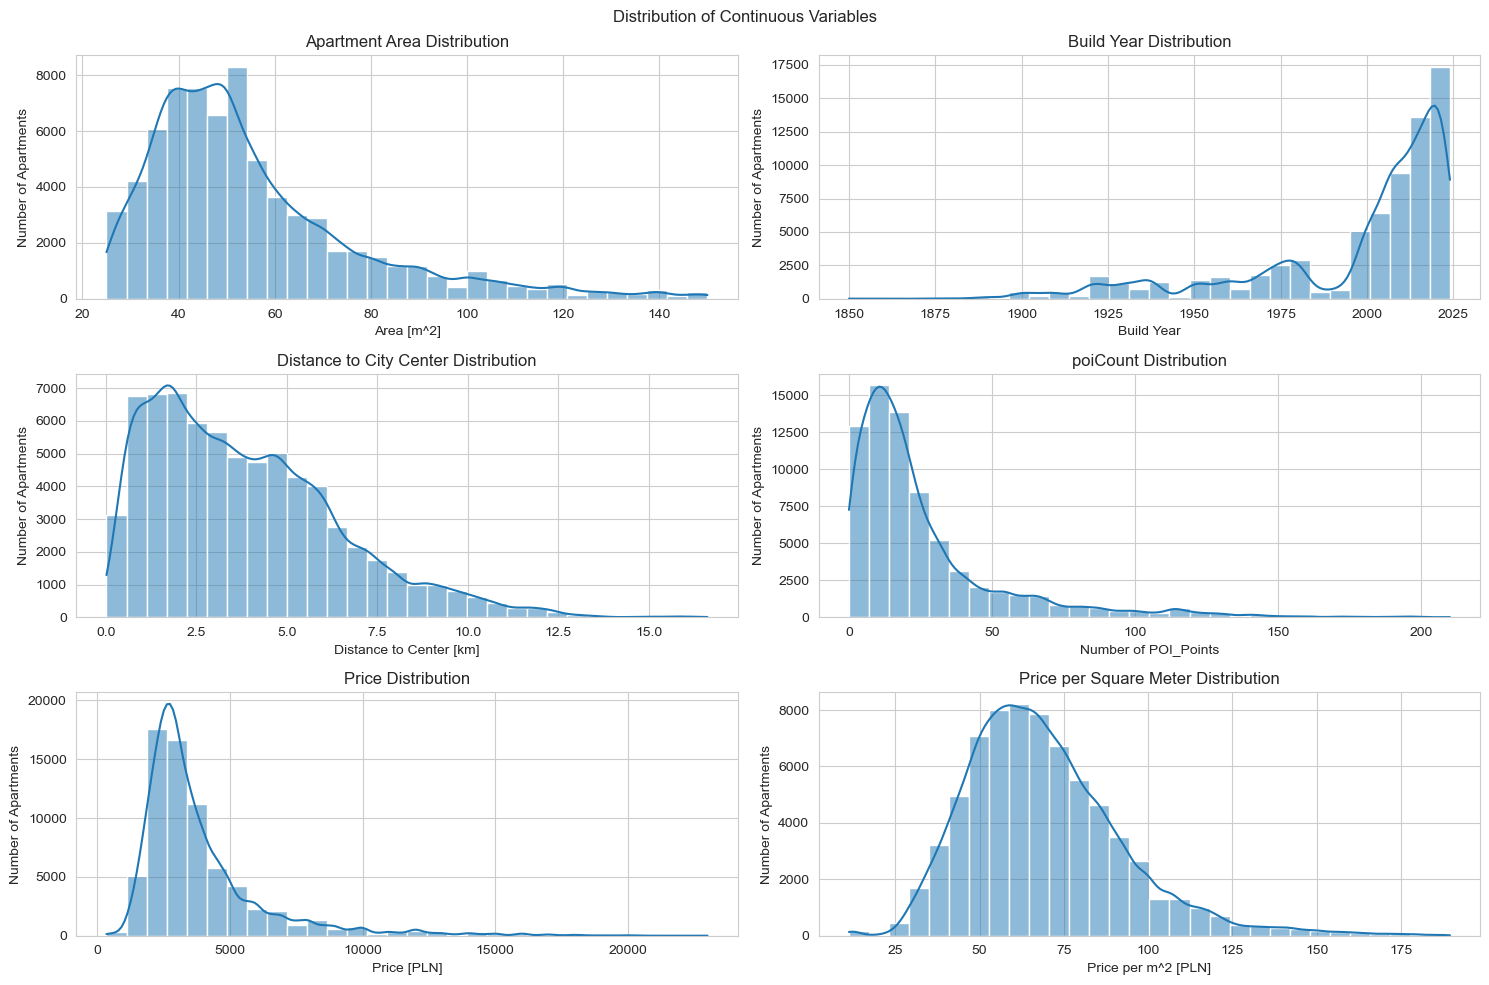

In [23]:
viz = DataVisualizer(df)
viz.histplots(continuous_columns, continous_titles, continuos_axis_x,3,2)

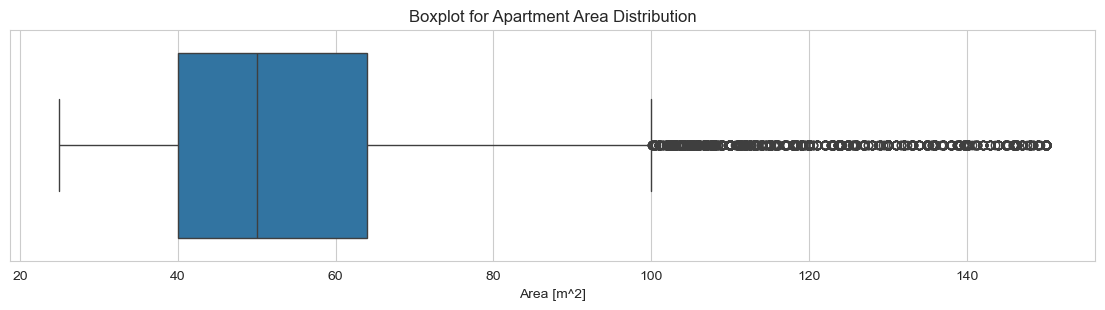

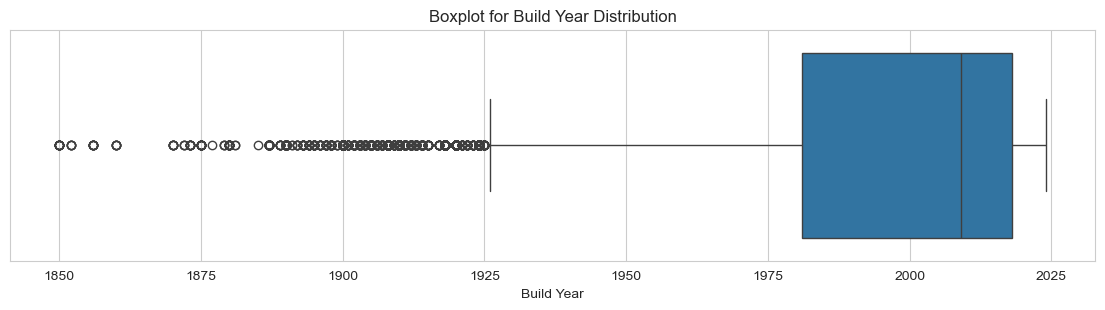

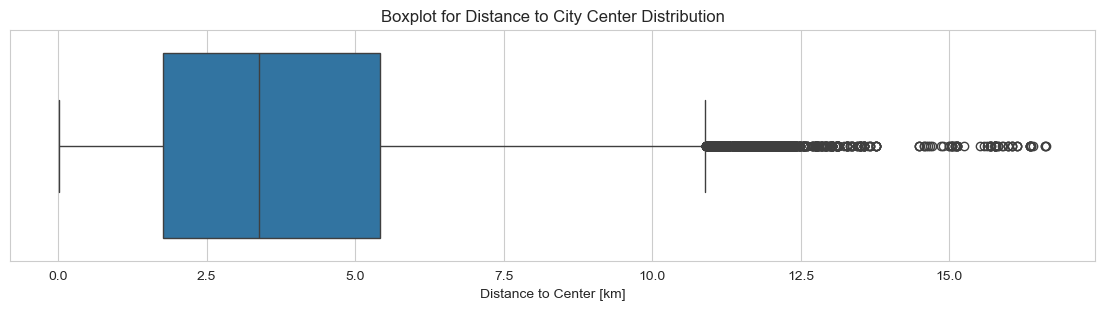

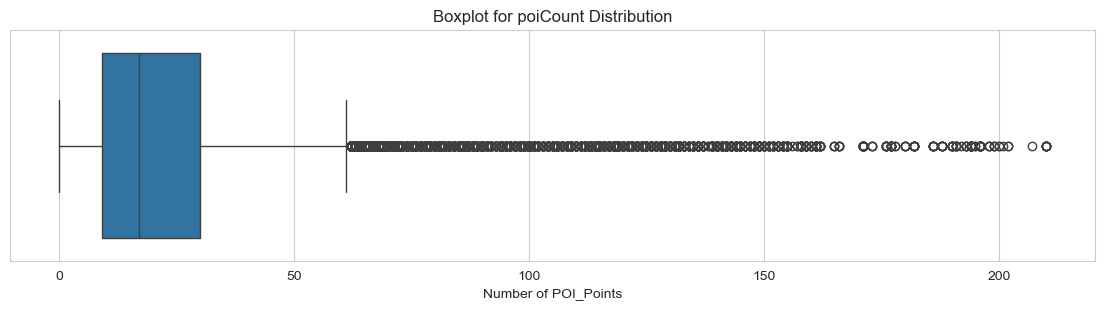

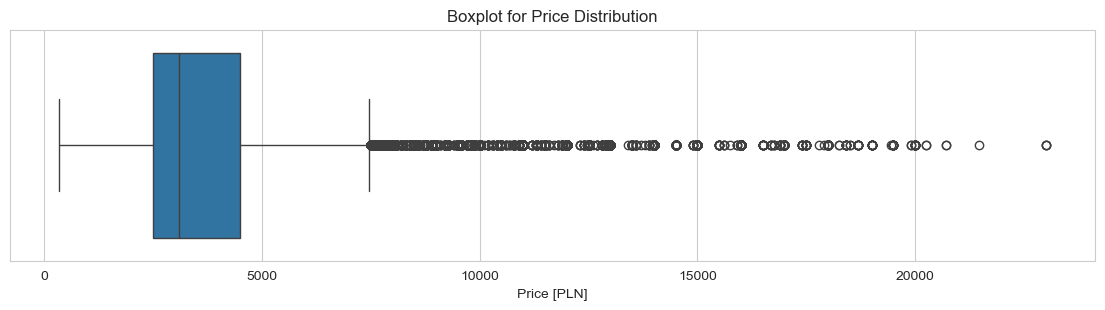

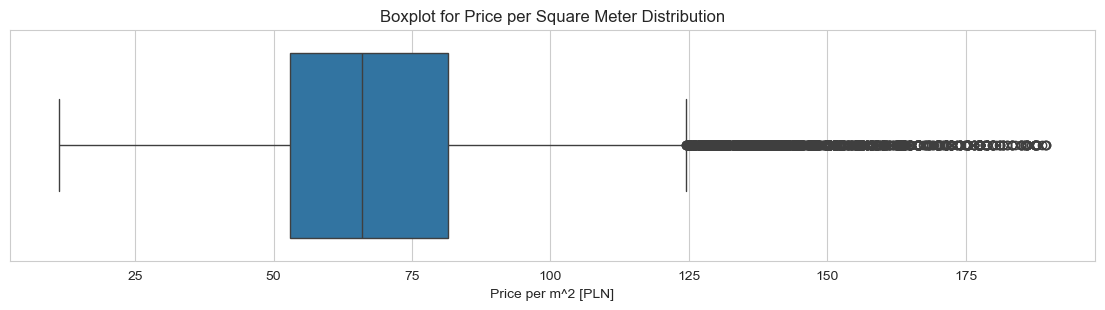

In [24]:
viz.boxplots(continuous_columns, continous_titles, continuos_axis_x)

In [25]:
df[['squareMeters','buildYear','centreDistance','poiCount','price','price_per_m2']].describe()

,squareMeters,buildYear,centreDistance,poiCount,price,price_per_m2
count,70847.000000,70847.000000,70847.000000,70847.000000,70847.000000,70847.000000
mean,55.252692,1997.250794,3.856228,25.207983,3852.796886,69.203438
std,22.688973,30.367567,2.609485,27.050432,2381.540981,23.349050
min,25.000000,1850.000000,0.020000,0.000000,346.000000,11.300000
25%,40.000000,1981.000000,1.770000,9.000000,2500.000000,53.000000
50%,50.000000,2009.000000,3.380000,17.000000,3100.000000,65.960000
75%,64.000000,2018.000000,5.420000,30.000000,4490.000000,81.580000
max,150.000000,2024.000000,16.620000,210.000000,23000.000000,189.470000


**Insights:**
* **Apartments Area:** - The data distribution is right-skewed. The middle 50% of all areas fall within the range of 40 $m^2$ to 64 $m^2$, while the bottom 25% of the smallest apartments range from 25 $m^2$ to 40 $m^2$. The median area is 50 $m^2$, whereas the mean is 55.25 $m^2$. The average area is inflated by a long right tail of apartments with an area > 100 $m^2$. This long tail does not consist of outliers; rather, it represents the luxury apartment market. Later in this analysis, I will investigate which property types (tenement, block of flats, apartment building) and which cities dominate this long right tail.
* **YearBuild:** - The data distribution is left-skewed with a long, flat left tail falling within the 1850-1950 range. These are not statistical outliers; the lack of newly built properties in these years is due to historical events such as the Partitions of Poland, World War I, and World War II. Between 1950 and 1990, we can observe two significant peaks caused by the construction of 'wielka płyta' (prefab concrete) housing blocks during the PRL era. In the 1990-2000 period, there is a noticeable decrease caused by the political and economic transition from communism to capitalism. From 2000 onwards, there is an almost constant increase in construction, with only minor fluctuations.
* **CityDistance:** -The data distribution is right-skewed. The first 25% of apartments fall within the range of 0 km (apartments in strict city centers) to about 1.7 km. The middle 50% are located between 1.7 km and 5.42 km from the center. The right tail does not represent outliers, but rather apartments located on the outskirts or near economic and industrial zones. The median distance is 3.38 km and the average is 3.85 km; the mean is inflated by the long right tail.
* **poiCount:** - The data distribution is strongly right-skewed. The middle 50% falls within the range of 9 to 30 POI points, showing that most apartments are not located in areas with a high density of points of interest. The long right tail likely suggests apartments located in the strict centers of large cities.
* **Price:** - The data distribution is strongly right-skewed. The middle 50% of prices fall within the range of 2,500 PLN to 4,490 PLN. The bottom 25% ranges from 346 PLN to 2,500 PLN. Here we can observe evident data entry errors, as 346 PLN for monthly rent in 2023/2024 is highly unrealistic. In the next step, I will filter all apartments with a price lower than 700 PLN and decide whether they are errors or not. The long right tail represents the top 25% of the most expensive apartments, ranging from 4,490 PLN to 23,000 PLN. Although prices above 15,000 PLN are noteworthy, the subsequent part of this analysis will verify whether there is any justification for such high valuations or if they result from data errors.
* **Price per $m^2$:** - The data distribution is right-skewed. The middle 50% falls within the range of 53 PLN/$m^2$ to 81.58 PLN/$m^2$, which in my opinion reflects the rental market in Poland very well. The first 25% of apartments range from 11.3 PLN/$m^2$ to 53 PLN/$m^2$. This indicates data errors, because 11.3 PLN per square meter in 2023/2024 is unrealistic; I will verify these suspiciously cheap apartments in the next step. The right tail shows the top 25% of the most expensive apartments, ranging from 81.56 PLN/$m^2$ to 189.47 PLN/$m^2$. Prices between 100 and 120 PLN/$m^2$ are realistic for standard premium housing, but the most expensive ones could either be highly luxurious new developments in major city centers or data anomalies. I will investigate this further.

## 4.4 Univariate Analysis: Distributions of Categorical and Discrete Variables

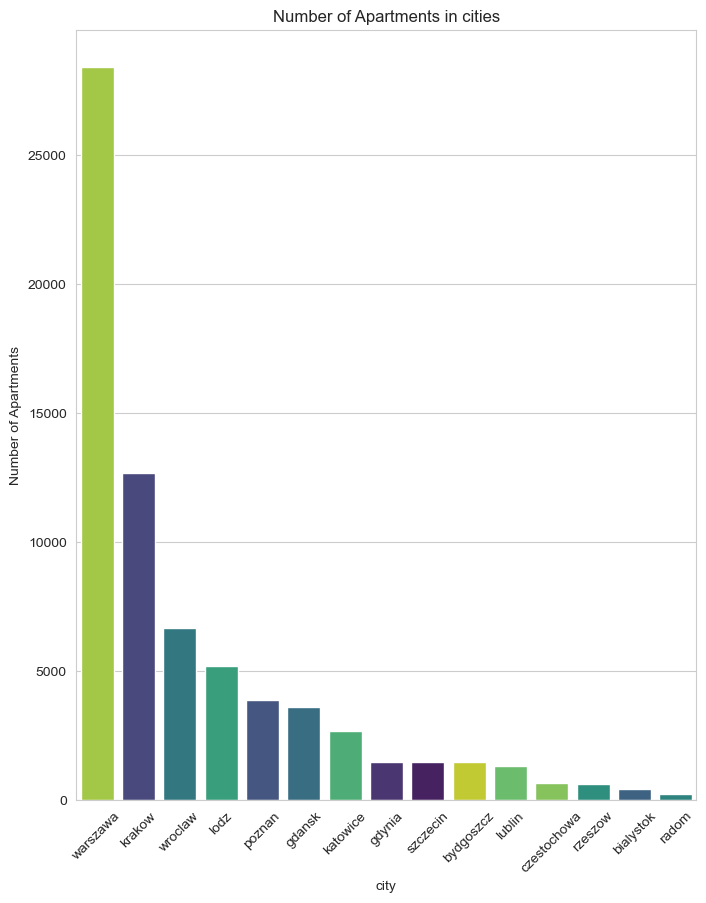

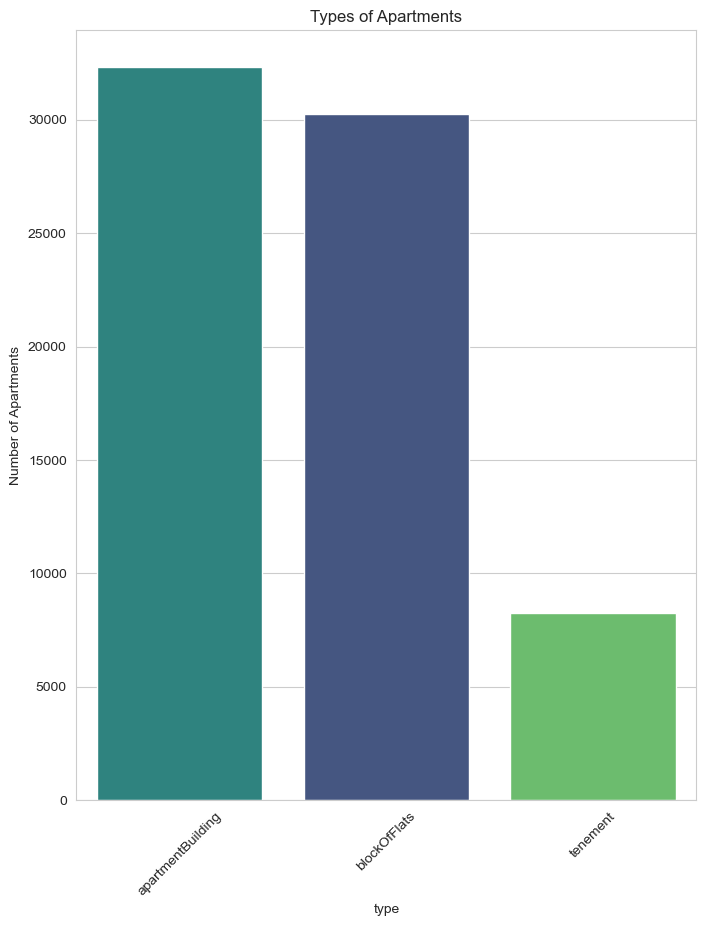

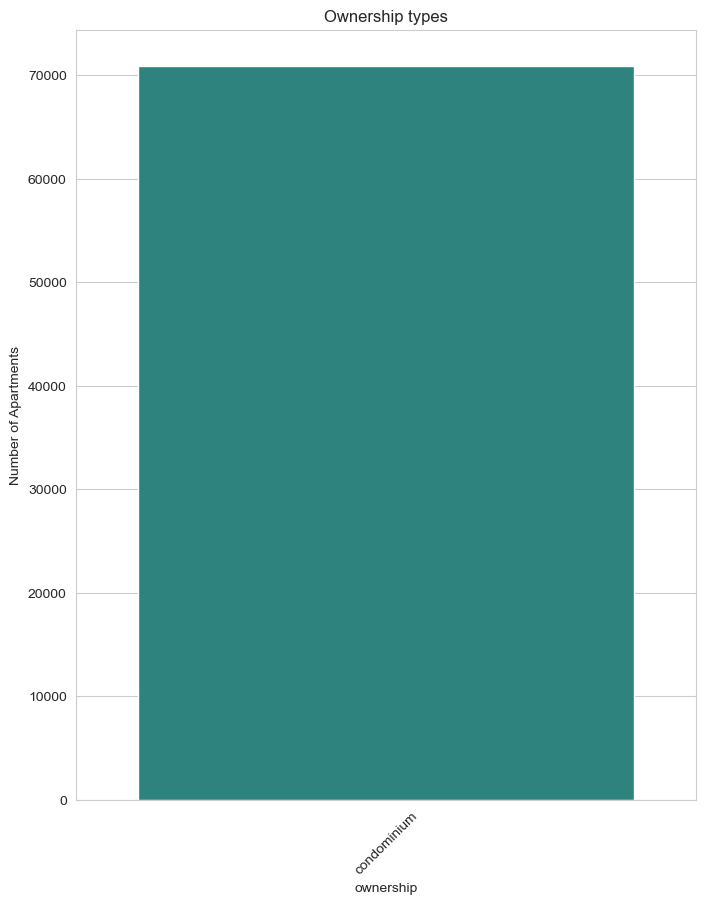

In [26]:
categorical_columns = ['city','type','ownership']
categorical_titles = [
'Number of Apartments in cities',
'Types of Apartments',
'Ownership types']
viz.countplots(categorical_columns,categorical_titles,'Number of Apartments')

In [27]:
df[['city','type','ownership']].describe()

,city,type,ownership
count,70847,70847,70847
unique,15,3,1
top,warszawa,apartmentBuilding,condominium
freq,28414,32326,70847


In [28]:
df['city'].value_counts(normalize=True) * 100

city
warszawa       40.106144
krakow         17.870905
wroclaw         9.423123
lodz            7.359521
poznan          5.490705
gdansk          5.074315
katowice        3.767273
gdynia          2.093243
szczecin        2.091832
bydgoszcz       2.086186
lublin          1.853289
czestochowa     0.932996
rzeszow         0.866656
bialystok       0.621057
radom           0.362754
Name: proportion, dtype: float64

In [29]:
df['type'].value_counts(normalize=True) * 100

type
apartmentBuilding    45.627902
blockOfFlats         42.728697
tenement             11.643401
Name: proportion, dtype: float64

**Insights:**
* **City:** - **Warszawa** dominates the rental market, accounting for about 40% of all offers. This is primarily driven by a huge job market and steady migration from smaller cities. The next tier includes **Kraków**, **Wrocław**, **Łódź**, **Poznań**, and **Gdańsk**, which collectively make up about 45% of the offers, experiencing a situation very similar to **Warszawa**. The relatively low number of offers in **Katowice** is intriguing; as a major provincial capital with a highly developed industrial and service sector, one might expect a higher volume, yet it constitutes only about 3.7% of the dataset. Next are **Gdynia**, **Szczecin**, **Bydgoszcz**, and **Lublin**, accounting for around 8% of total offers. Again, the low availability in major cities like **Gdynia** and **Szczecin** is noteworthy. Finally, **Częstochowa**, **Rzeszów**, **Białystok**, and **Radom** contribute a combined total of about 3%, which is perfectly normal given their smaller industrial and service sectors.
* **Type:** - **Block of Flats** constitutes the largest share of offers at approximately 45%. At this stage, it is difficult to determine how many of these are older PRL-era buildings versus modern block developments; I will investigate this in the next steps of the analysis. **Apartment** Buildings make up about 37% of the offers, indicating a dynamically growing modern housing market. The remaining 18% consists of **Tenements**.
* **Ownership:** - **Condominium** is the only ownership type present in this dataset, meaning all listed properties are privately owned apartments.


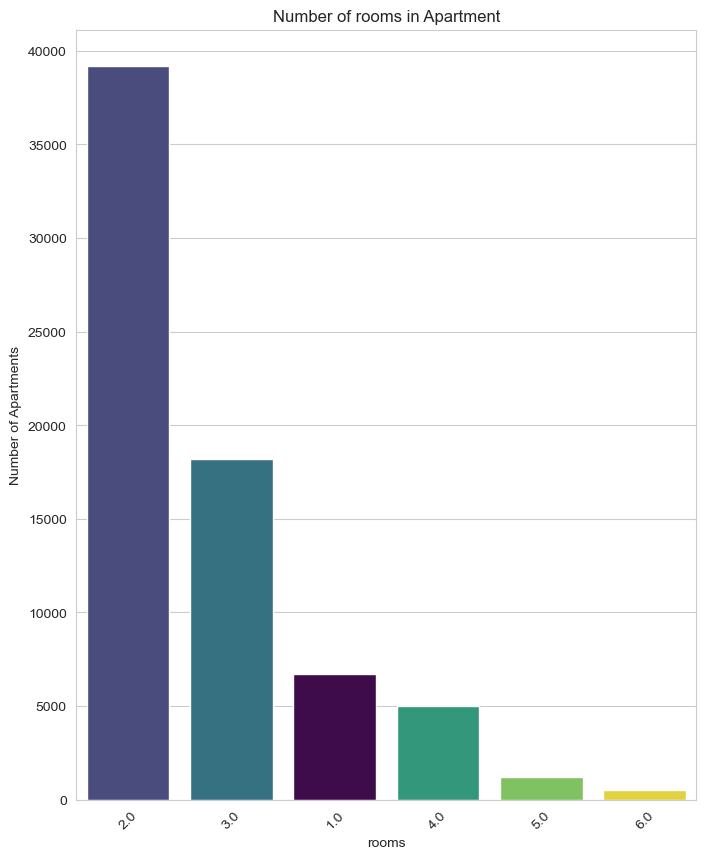

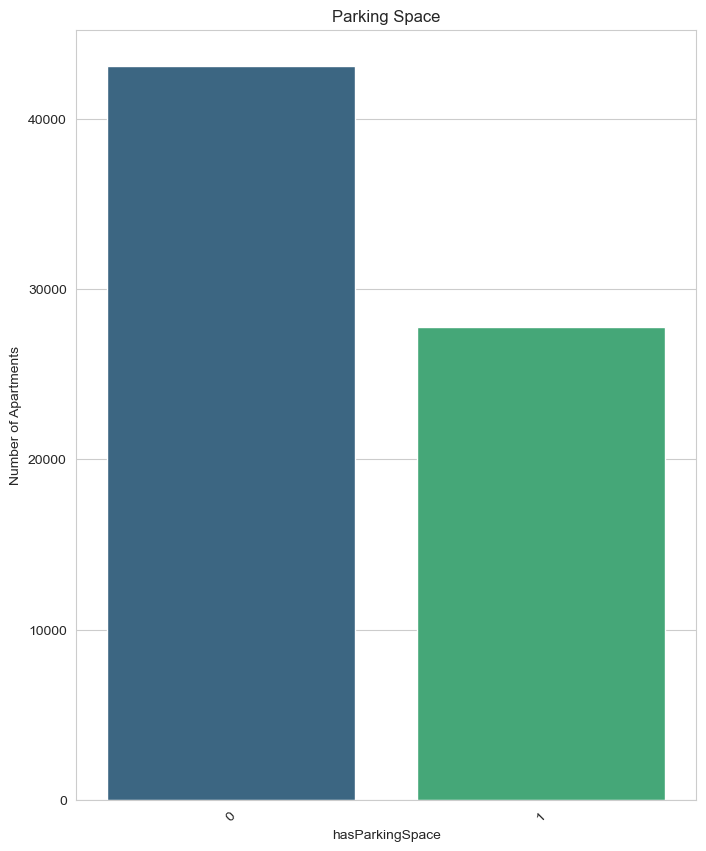

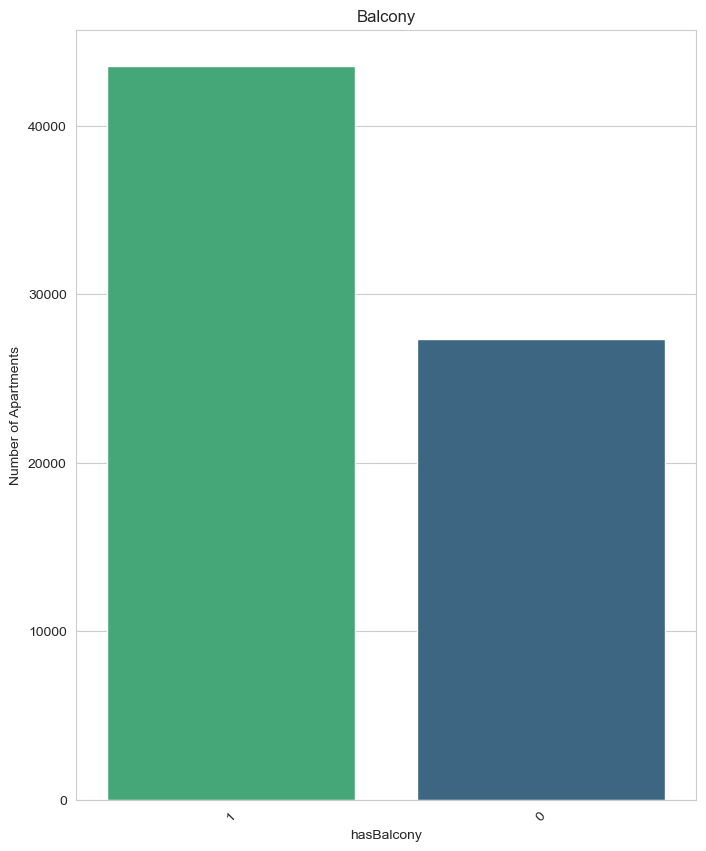

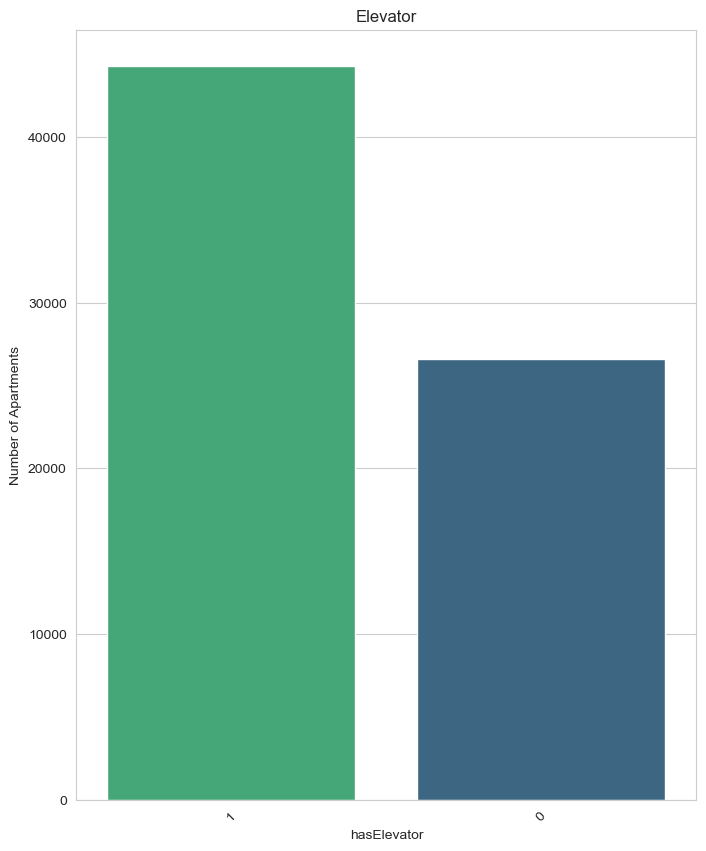

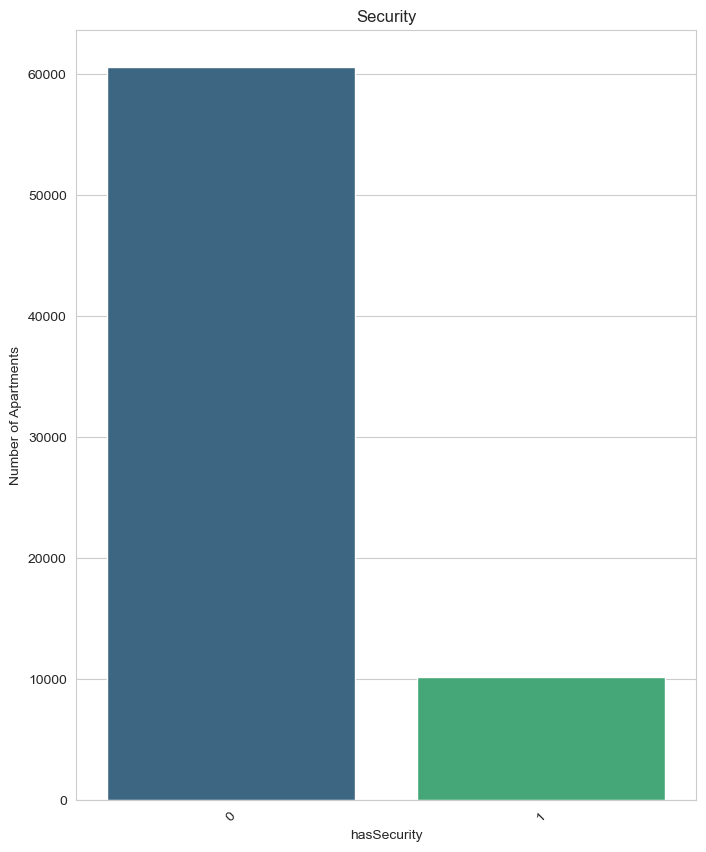

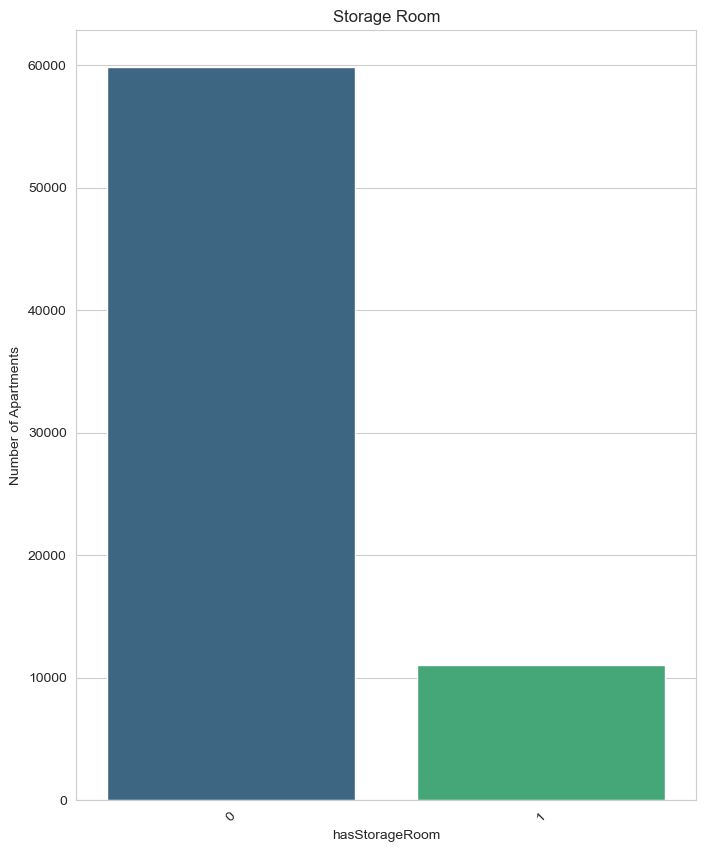

In [30]:
discrete_columns = ['rooms','hasParkingSpace','hasBalcony','hasElevator','hasSecurity','hasStorageRoom']
discrete_titles = [
    'Number of rooms in Apartment',
    'Parking Space',
    'Balcony',
    'Elevator',
    'Security',
    'Storage Room']
viz.countplots(discrete_columns, discrete_titles,'Number of Apartments')

In [31]:
df['rooms'].value_counts(normalize=True) * 100

rooms
2.0    55.300860
3.0    25.704688
1.0     9.473937
4.0     7.046170
5.0     1.726255
6.0     0.748091
Name: proportion, dtype: float64

In [32]:
df['hasParkingSpace'].value_counts(normalize=True) * 100

hasParkingSpace
0    60.800034
1    39.199966
Name: proportion, dtype: float64

In [33]:
df['hasBalcony'].value_counts(normalize=True) * 100

hasBalcony
1    61.408387
0    38.591613
Name: proportion, dtype: float64

In [34]:
df['hasElevator'].value_counts(normalize=True) * 100

hasElevator
1    62.448657
0    37.551343
Name: proportion, dtype: float64

In [35]:
df['hasSecurity'].value_counts(normalize=True) * 100

hasSecurity
0    85.556199
1    14.443801
Name: proportion, dtype: float64

In [36]:
df['hasStorageRoom'].value_counts(normalize=True) * 100

hasStorageRoom
0    84.453823
1    15.546177
Name: proportion, dtype: float64

**Insights**
* **rooms:** - Two-room apartments are dominant, accounting for over 55% of listings. This suggests that most properties are located in **blockOfFlats**, where the most common layout consists of two rooms, a bathroom, and a kitchen. Three-room apartments account for over 25% of listings and are likely either larger apartments in **blockOfFlats** (typically above 50 m²) or units located in **tenement** buildings. Single-room apartments represent around 9% of listings; however, market trends suggest that the number of such apartments may increase in the future. Apartments with four to six rooms account for only about 2% of listings and are most likely found in large **apartments** or bigger **tenement** buildings rather than typical **blockOfFlats**.
* **ParkingSpace**: - Only about 39% of apartments have a parking space. This is relatively normal for dense urban areas where parking availability is limited. In the future, the proportion of apartments without dedicated parking spaces may increase.
* **Balcony:** - Over 61% of apartments have a balcony, which indicates that balconies are a common feature in residential buildings.
* **Elevator:** - More than 62% of apartments have access to an elevator, which further suggests that the majority of listings come from **blockOfFlats** or modern **apartment** buildings.
* **Security:** - Only 14.5% of apartments have security systems or building security, which indicates that the market share of luxury or high-standard apartments is relatively small.
* **StorageRoom:** - Around 15% of apartments include a storage room. These units are more likely to be located in **tenement** buildings or older residential buildings where additional storage spaces are common.

## 4.5 Correlations Heatmap

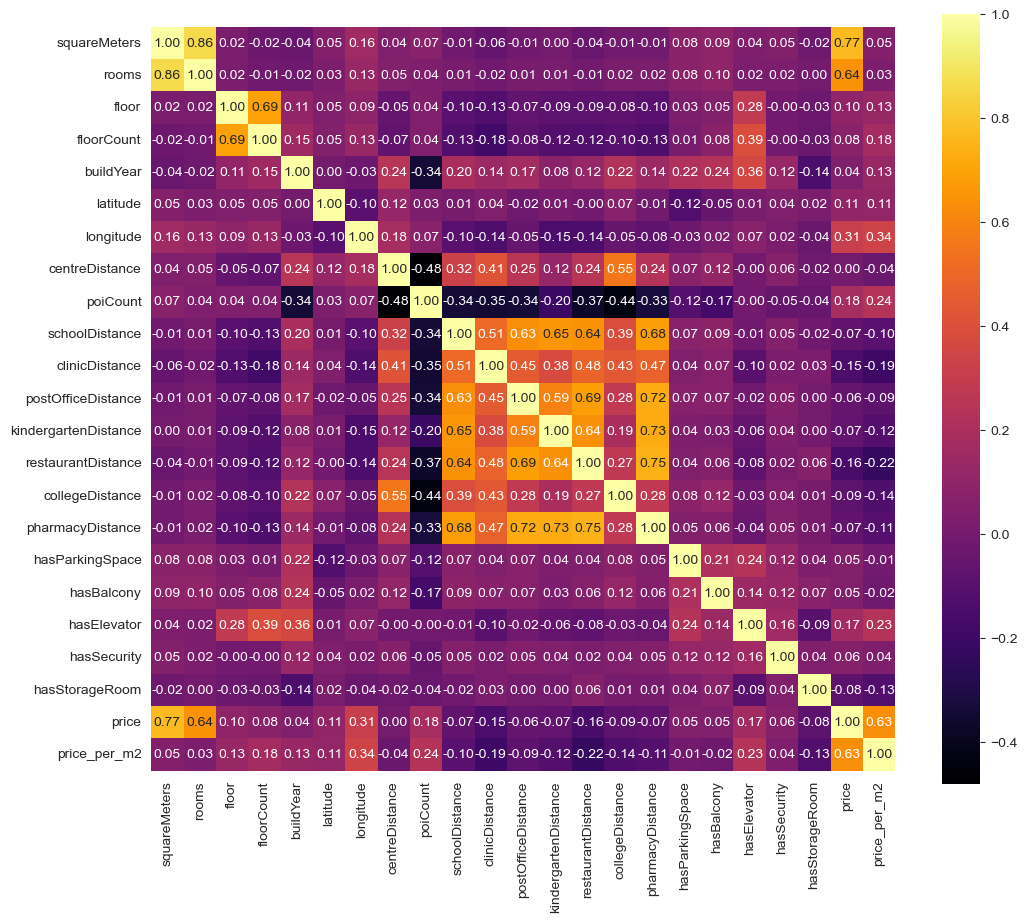

In [37]:
viz.heatmap()

In [38]:
df_numeric = df.select_dtypes(include='number')

In [39]:
correl = df_numeric.corr()['price']

In [40]:
correl.sort_values(ascending=False)

price                   1.000000
squareMeters            0.765885
rooms                   0.644158
price_per_m2            0.632070
longitude               0.311590
poiCount                0.180689
hasElevator             0.165599
latitude                0.107829
floor                   0.095554
floorCount              0.079375
hasSecurity             0.058489
hasParkingSpace         0.050958
hasBalcony              0.045474
buildYear               0.041702
centreDistance          0.002126
postOfficeDistance     -0.057635
kindergartenDistance   -0.065858
pharmacyDistance       -0.069568
schoolDistance         -0.070787
hasStorageRoom         -0.083038
collegeDistance        -0.085755
clinicDistance         -0.146802
restaurantDistance     -0.155073
Name: price, dtype: float64

**Insights:**

Apartment price is positively correlated with square meters (r = 0.77) and number of rooms (r = 0.64). This indicates that larger apartments and those with more rooms tend to have higher prices.
We can also observe a slight positive correlation with location variables, such as latitude (r = 0.31) and longitude (r = 0.10), although these relationships are relatively weak.
Based on these results, it can be assumed that the main factors influencing apartment prices are the size of the apartment and the number of rooms, while the remaining variables appear to have only a marginal influence on price.

## 4.6 Investigating Price Anomalies

In this part of analysis I check unreasonable low price (**price** < 1000 PLN and **price_per_m2** < 30 PLN/$m^2$) and unreasonable high price (**price** > 15000 PLN and **price_per_m2** > 120 PLN/$m^2$).

### 4.6.1 Unreasonably low price

In [57]:
df[(df['price'] < 1000) & (df['price_per_m2'] < 30)].sort_values(by=['price','price_per_m2'])[['city','type','price','squareMeters','price_per_m2']]

,city,type,price,squareMeters,price_per_m2
30684,katowice,blockOfFlats,346,30.36,11.40
30545,katowice,blockOfFlats,347,28.41,12.21
30555,katowice,blockOfFlats,371,32.79,11.31
30617,katowice,blockOfFlats,380,32.50,11.69
30657,katowice,apartmentBuilding,399,35.00,11.40
...,...,...,...,...,...
4637,czestochowa,tenement,980,81.00,12.10
4638,czestochowa,tenement,980,81.00,12.10
22084,czestochowa,tenement,980,81.00,12.10
22085,czestochowa,tenement,980,81.00,12.10


In [55]:
df[(df['price'] < 1000) & (df['price_per_m2'] < 30)].sort_values(by=['price','price_per_m2'])[['city','type','price','squareMeters','price_per_m2']].head(20)

,city,type,price,squareMeters,price_per_m2
30684,katowice,blockOfFlats,346,30.36,11.40
30545,katowice,blockOfFlats,347,28.41,12.21
30555,katowice,blockOfFlats,371,32.79,11.31
30617,katowice,blockOfFlats,380,32.50,11.69
30657,katowice,apartmentBuilding,399,35.00,11.40
30636,katowice,blockOfFlats,400,34.79,11.50
21815,katowice,apartmentBuilding,401,34.30,11.69
30683,katowice,blockOfFlats,405,35.55,11.39
4342,katowice,apartmentBuilding,405,30.70,13.19
30600,katowice,apartmentBuilding,406,35.60,11.40


In [56]:
df[(df['price'] < 1000) & (df['price_per_m2'] < 30)].sort_values(by=['price','price_per_m2'])[['city','type','price','squareMeters','price_per_m2']].tail(20)

,city,type,price,squareMeters,price_per_m2
65745,radom,blockOfFlats,800,29.00,27.59
21646,katowice,blockOfFlats,839,66.08,12.70
48417,katowice,blockOfFlats,839,66.08,12.70
66903,katowice,blockOfFlats,839,66.08,12.70
4328,katowice,tenement,900,43.00,20.93
13327,katowice,tenement,900,43.00,20.93
21837,katowice,tenement,900,43.00,20.93
30653,katowice,tenement,900,43.00,20.93
39219,katowice,tenement,900,43.00,20.93
48454,katowice,tenement,900,43.00,20.93


**Insights:**

The query above revealed 166 extreme anomalies where both total rental price is belove 1000 PLN and price per square meter is belove 30PLN/$m^2$. In the current reality of Polish real estate market, these values are entirely unrealistic for independent apartments. They most likely represent data entry errors, sigle rooms miscassified as full properties or fake 'bait'listings.
 I decided to remove these records from the dataset.

In [62]:
len(df)

70847

In [68]:
df = df[(df['price'] >= 1000) & (df['price_per_m2'] >= 30)]

In [83]:
viz = DataVisualizer(df)

In [84]:
len(df)

70054

**Insights:**

As dictated by boolen logic, this aperation removed 793 records. It successfully filtered out not only 166 extreme cases but albo records that failed at least one on the criteria such as:
* Properties with an unrealistic total price < 1000 PLN but a normal price per square meter.
* Properties with a seemingly normal total price nut an impossibly low price per square meter < 30PLN/$m^2$
  

### 4.6.2 Unreasonably high price

In [85]:
df[(df['price'] > 15000) & (df['price_per_m2'] > 120)].sort_values(by='squareMeters')[['city','type','squareMeters','price','price_per_m2']]

,city,type,squareMeters,price,price_per_m2
31964,warszawa,tenement,85.61,15741,183.87
32784,warszawa,blockOfFlats,90.00,17000,188.89
8171,warszawa,apartmentBuilding,94.00,15500,164.89
25536,warszawa,apartmentBuilding,94.00,15500,164.89
51219,warszawa,apartmentBuilding,94.00,16000,170.21
...,...,...,...,...,...
8111,warszawa,tenement,150.00,20000,133.33
17020,warszawa,tenement,150.00,20000,133.33
25487,warszawa,tenement,150.00,20000,133.33
30983,warszawa,apartmentBuilding,150.00,20000,133.33


In [86]:
df[(df['price'] > 15000) & (df['price_per_m2'] > 120)].sort_values(by='squareMeters')[['city','type','squareMeters','price','price_per_m2']].head(20)

,city,type,squareMeters,price,price_per_m2
31964,warszawa,tenement,85.61,15741,183.87
32784,warszawa,blockOfFlats,90.00,17000,188.89
8171,warszawa,apartmentBuilding,94.00,15500,164.89
25536,warszawa,apartmentBuilding,94.00,15500,164.89
51219,warszawa,apartmentBuilding,94.00,16000,170.21
40721,warszawa,apartmentBuilding,94.00,16000,170.21
60999,warszawa,apartmentBuilding,94.00,16000,170.21
17069,warszawa,apartmentBuilding,94.00,15500,164.89
70101,warszawa,apartmentBuilding,94.00,16000,170.21
16984,warszawa,apartmentBuilding,97.00,17000,175.26


In [87]:
df[(df['price'] > 15000) & (df['price_per_m2'] > 120)].sort_values(by='squareMeters')[['city','type','squareMeters','price','price_per_m2']].tail(20)

,city,type,squareMeters,price,price_per_m2
13750,warszawa,tenement,146.0,20250,138.70
22576,warszawa,apartmentBuilding,146.0,20000,136.99
16208,warszawa,apartmentBuilding,146.0,20700,141.78
22217,warszawa,tenement,146.0,20250,138.70
24675,warszawa,apartmentBuilding,146.0,20700,141.78
49293,warszawa,apartmentBuilding,146.0,18000,123.29
5047,warszawa,apartmentBuilding,146.0,20000,136.99
67801,warszawa,apartmentBuilding,146.0,18000,123.29
58765,warszawa,apartmentBuilding,146.0,18000,123.29
33120,warszawa,blockOfFlats,147.6,23000,155.83


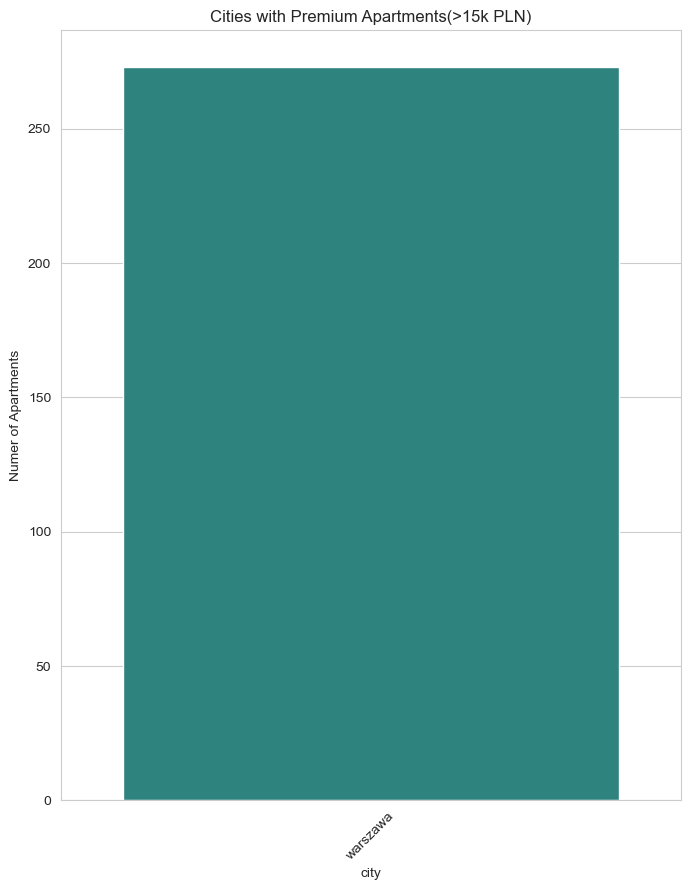

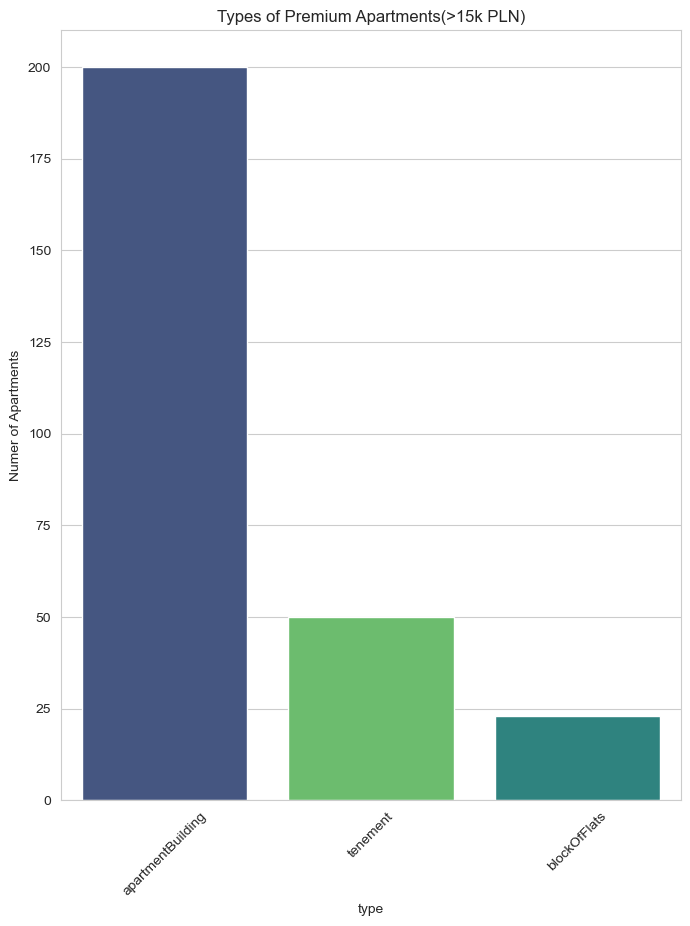

In [88]:
df_premium = df[(df['price'] > 15000) & (df['price_per_m2'] > 120)]
premium_columns = ['city','type']
premium_title = ['Cities with Premium Apartments(>15k PLN)','Types of Premium Apartments(>15k PLN)']
viz_premium = DataVisualizer(df_premium)
viz_premium.countplots(premium_columns,premium_title,'Numer of Apartments')

In [89]:
df_lux = df[(df['price'] > 15000) &(df['price_per_m2'] > 120)]
df_lux.groupby('type')['centreDistance'].median()

type
apartmentBuilding    1.890
blockOfFlats         1.400
tenement             1.435
Name: centreDistance, dtype: float64

**Insights:**
I also invesitgated the upper tail of distribution, specifically filtering for properties with a monthly rent above 15000 PLN and price per square meter above 120PLN/$m^2$. This query returned 273 records.
A closer inspection revealed that there are not data entry errors. The properties are excepionally large (mostly 90-150 $m^2$) and are located exclusively in **Warszawa**. Breaking down these records by building type perfectly reflects the reality of the luxury real estate market:
* **Apartment Buildings (about 200 records)** - Modern luxury apartments and penthauses in premium high-rises.
* **Tenement (about 50 records)** - Fully revitalized, historic buildings with high ceilings.
* **BlockOfFlats (about 23 records)** - High-end modern gated communities that agents categorized as standad blocks rather than premium apartments
* **Crucially, I verified the location of these extreme outliers using the distance to the city center.** The data confirms their premium status: the median distance to the center for all these building types falls strictly between **1.4 and 1.9 km**. This places them unequivocally in the prime, strict city center (Śródmieście).
* Since these listings accurately represent the legitimate premium and luxury rental sector targeted at executives, expats, and diplomats, I deliberately decided to retain them in the dataset.

## 4.7 Bivoriate Analysis & Hypotheses Testing

In this part of analysis I will check variables with the most correlations **squareMeters(r=0.77)** and **rooms(r=0.64)**. Then I will check how many **blockOfFlats** are from PRL.

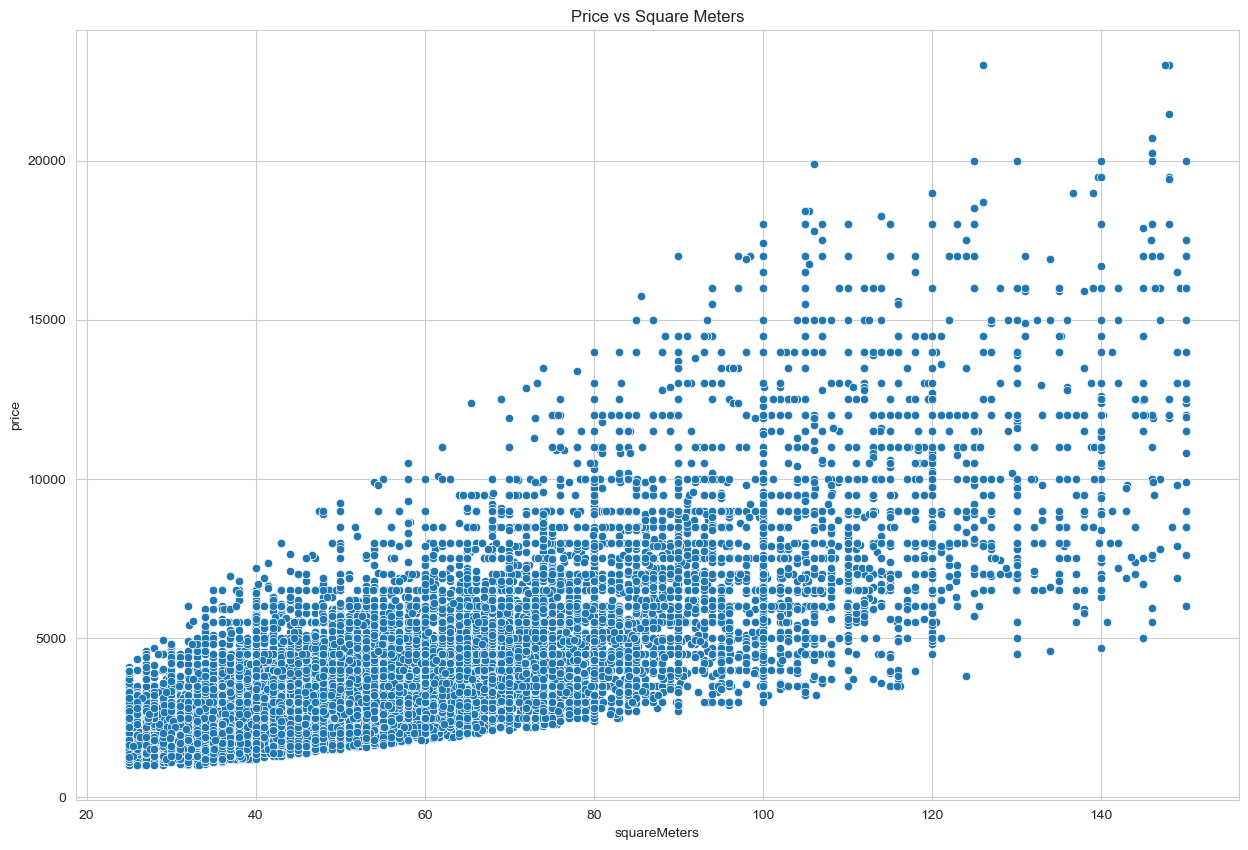

In [90]:
viz.scatterplots('squareMeters','price','Price vs Square Meters')

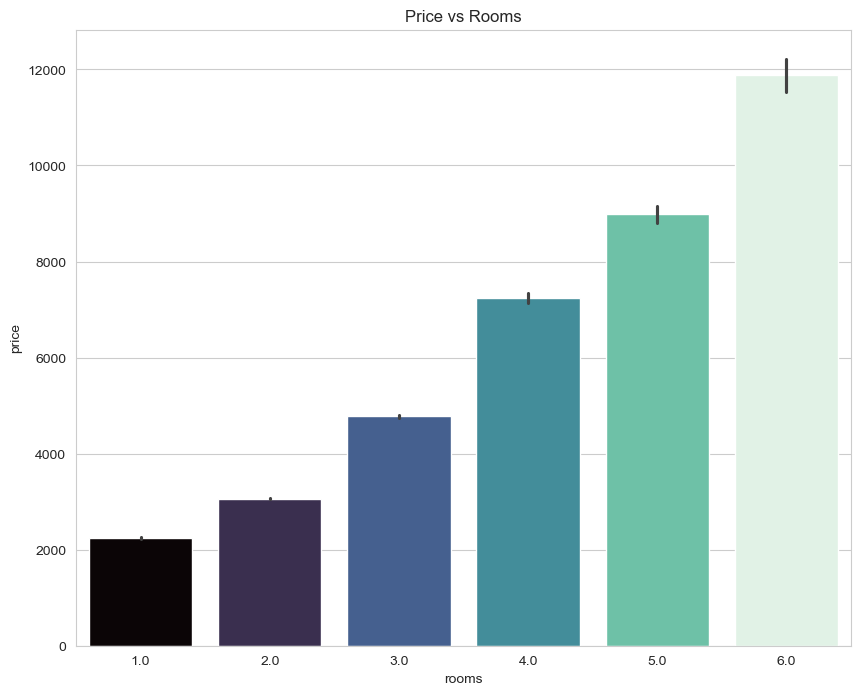

In [91]:
viz.barplots('rooms','price','Price vs Rooms')

**Insights:**

Visualizing the reletionship between rental price, property size and room count reveals key market dynamics:
* **Strong positive trend** - The scatterplot shows a clear positive linear trend-larger area dictates a higher baseline price. The barplot for room count confirms this with a visible, step-by-step price increase for every addictional room.
* **Increasing variance** - The scatterplot forms a distinct funnel shape. For small to medium apartments(approx. 25-60 $m^2$), the price variance is minimal-they are priced within a relatively tight range. However, for properties larger than 60 $m^2$ and expecially above 100 $m^2$, the price dispersion becomes massive. This proves tha for larger properties, the price is no longer driven promarily by square foottage, but heavily depends on the standard, building type and exact location.

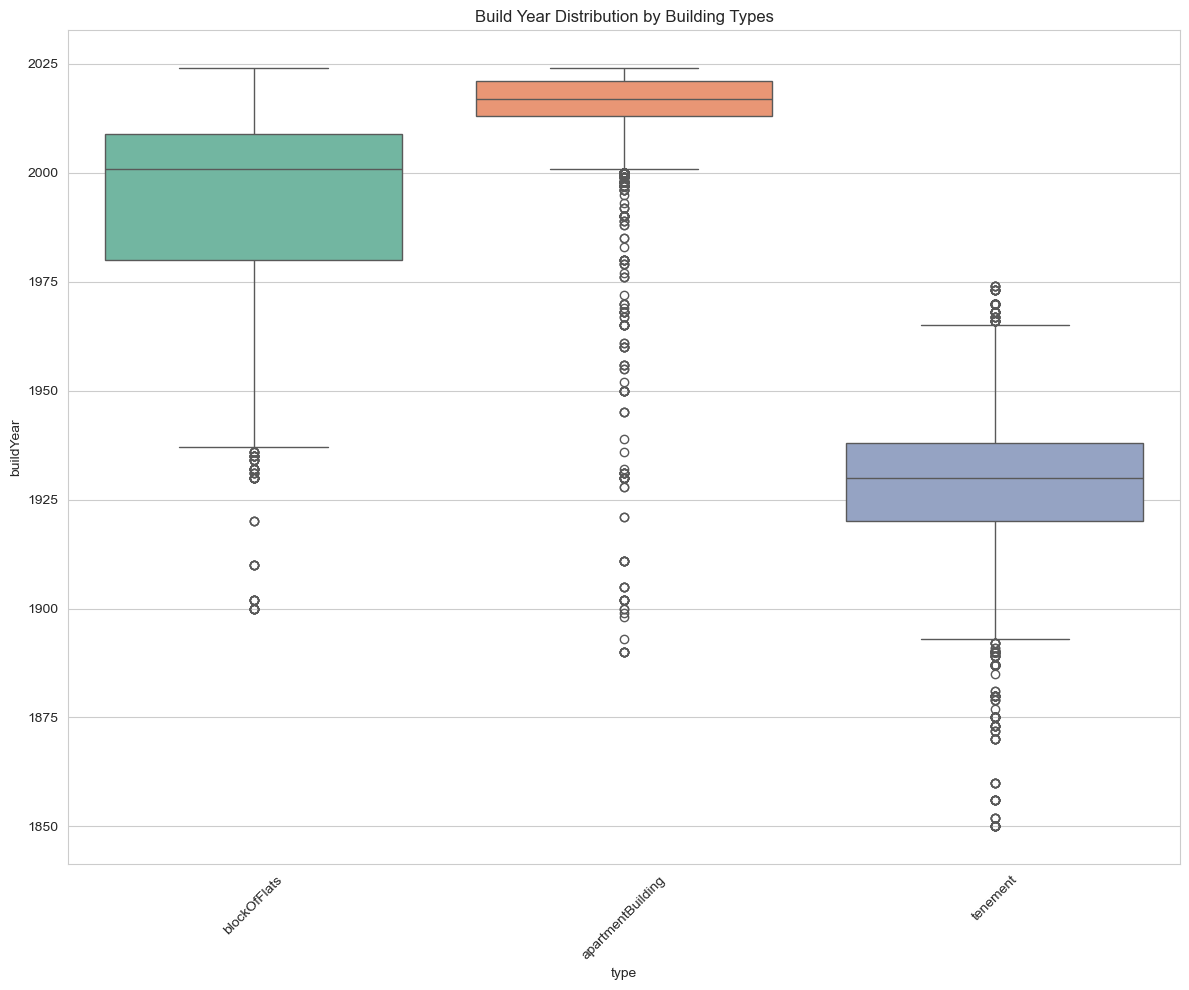

In [92]:
viz.bivariate_boxplot('type','buildYear','Build Year Distribution by Building Types')

**Insights:**

The distribution of build year across different property types reveals distinct historical and market patterns:
* **Tenements** - As expected this category is predominantly historical with the interquartile range firmly set between 1920 and 1940.
* **BlockOfFlats** - The median build year sits surprisingly high, around 2000. This challenges the common assumption that blockOfFlats represent older, Soviet-era housing. The market clearly categorizes many stnadard modern developer projekcts from 2000s and 2010s in this group.
* **Apartments Buildings** - This category is overwhelmingly modern post 2010. However it exhibits a massive tail of historical outliers reaching as far back as 1850. Business domain knowledge explains this perfectly these are fully revitalized, premium historic tenements marketed by real estate agencies as "luxury-apartmnets" to jutify higher rental prices.


## 4.8 Time Series Analysis

In this section, I will investigate the price history of the top 10 most dynamic listings and analyze the average rental price trends in various cities.

In [93]:
top_10_idx = df.groupby('id')['price'].nunique().sort_values(ascending=False).head(10).index
df_top10 = df[df['id'].isin(top_10_idx)].sort_values(['id','price'])

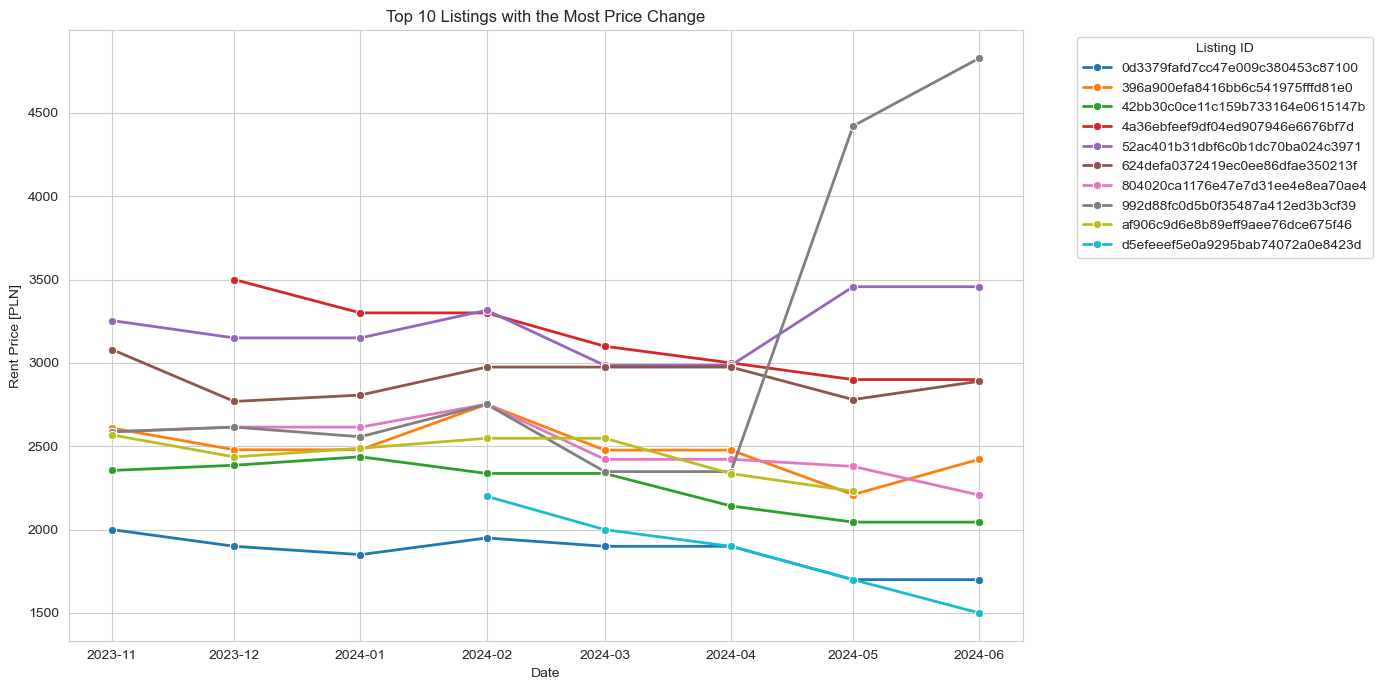

In [94]:
viz_top_10 = DataVisualizer(df_top10)
viz_top_10.lineplots('date','price','id','tab10','Top 10 Listings with the Most Price Change','Rent Price [PLN]','Listing ID')

**Insights:** 

Tracking the top 10 listings with the most frequent price fluctuations highlights varying landlord and agency strategies:
* **Market Correction** - Many lines show a step-by-step decrease in rent over time. This indicates an initial overvaluation by the owner, followed by forced price cuts due to low market demand.
* **Market Testing** - Several listings exhibit a pattern where the price increases to a certain peak and then subsequently drops. This reflects "price discovery"—owners or agents testing the market's upper limits (e.g., anticipating seasonal demand) but being forced to lower the rent again when the property fails to attract tenants at the elevated price.
* **Extreme Adjustments** - A notable anomaly is visible (the grey line), where a property's rent suddenly skyrocketed. In real estate data, massive jumps usually indicate a fundamental change in the offering, such as a luxury renovation or upgrading to a fully furnished standard.


In [95]:
df_average_price = df.groupby(['city','date'])['price'].mean()
df_avg = pd.DataFrame(df_average_price)

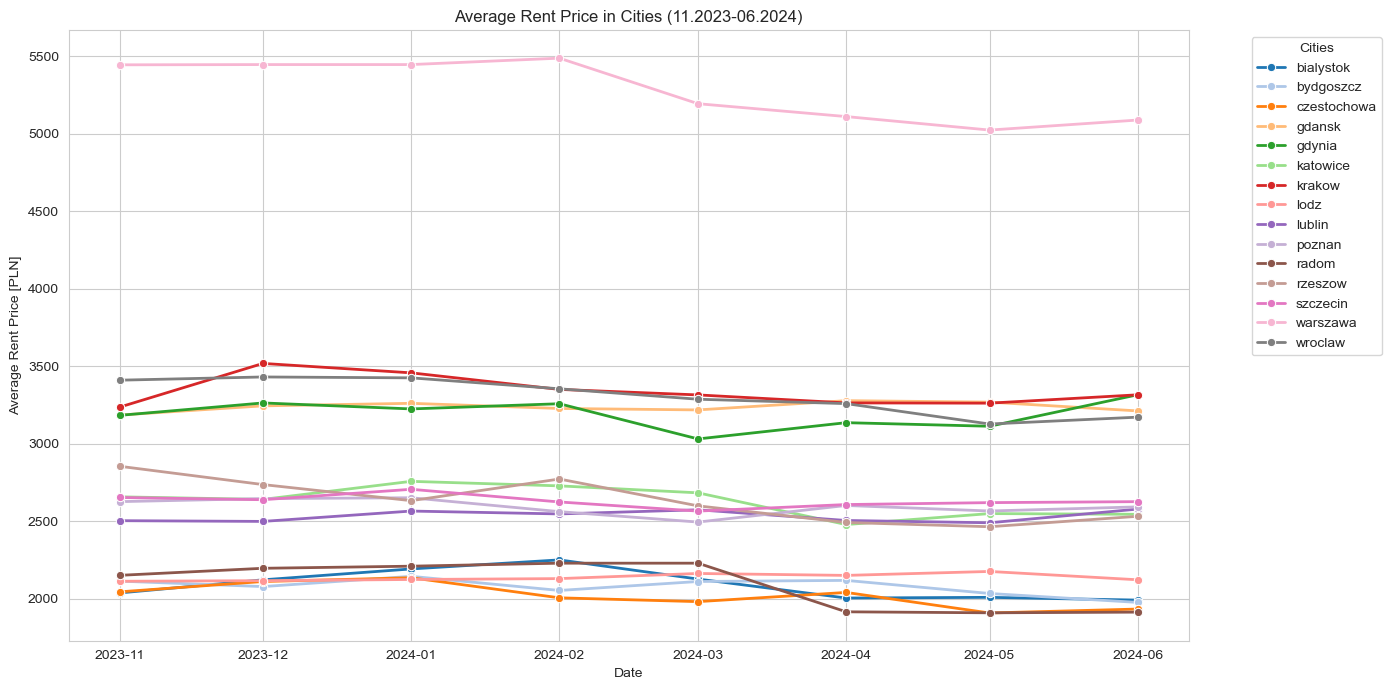

In [96]:
viz_avg = DataVisualizer(df_avg)
viz_avg.lineplots('date','price','city','tab20','Average Rent Price in Cities (11.2023-06.2024)','Average Rent Price [PLN]','Cities')

**Insights:**

The time series analysis of average rental prices across major cities (Nov 2023 - Jun 2024) shows a clear market hierarchy and stabilization:
* **The Warsaw Premium:** Warszawa completely dominates the landscape as a distinct premium market, consistently averaging around 5,000–5,500 PLN, far above any other location.
* **The Middle and Lower Tiers:** Cities like Kraków, Wrocław, Gdynia and Gdańsk form a solid middle tier (~3,000–3,500 PLN), while the remaining regional cities cluster tightly in the 2,000–2,500 PLN range.
*  **Spring Correction & Early Summer Rebound:** After a period of relative stability and slight peaks around February 2024, a noticeable downward correction occurred throughout the spring (March to May) across several major cities, including Warsaw and Gdynia. However, by the end of Q2 (June 2024), this downward trend halted, and average prices showed signs of stabilization or a slight upward rebound, likely anticipating the upcoming summer/student season.

# 5. Data Export

In [ ]:
df = df.reset_index(drop=True)
df.to_csv('cleaned_rent_data.csv', index=False)